### Лабораторная 2

# Задание

Попробовать методы регрессии на своих наборах данных.
Работа будет засчитана, если коэффициент детерминации будет не меньше, чем 0.85.
Чтобы достигнуть этой метрики вам понадобится:
1. Сгенерировать рандомный датасет для регрессии
1. проанализировать их
1. предобработать данные
1. попробовать разные методы регрессии
1. получить метрики
1. визуализировать регрессию на одном из параметров

#### Необходимые библиотеки

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

#### 1.Загружаем датасет, получаем общую информацию о датасете

In [25]:
df = pd.read_csv("MathEdataset.csv", sep=";", encoding="cp1251")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")
print(df.head())

Строк: 9546, Столбцов: 8
   Student ID Student Country  Question ID  Type of Answer Question Level  \
0         647         Ireland           77               0          Basic   
1          41        Portugal           77               1          Basic   
2         340        Portugal           77               1          Basic   
3         641           Italy           77               0          Basic   
4         669        Portugal           77               1          Basic   

        Topic    Subtopic                                           Keywords  
0  Statistics  Statistics  Stem and Leaf diagram,Relative frequency,Sampl...  
1  Statistics  Statistics  Stem and Leaf diagram,Relative frequency,Sampl...  
2  Statistics  Statistics  Stem and Leaf diagram,Relative frequency,Sampl...  
3  Statistics  Statistics  Stem and Leaf diagram,Relative frequency,Sampl...  
4  Statistics  Statistics  Stem and Leaf diagram,Relative frequency,Sampl...  


### 2.Теперь нам нужно сделать анализ данных датасета. Типы данных, пропуски, описательная статистика, точность по признакам (с визуализацией)

#### ТИпы данных

In [26]:
print(df.dtypes)

Student ID          int64
Student Country    object
Question ID         int64
Type of Answer      int64
Question Level     object
Topic              object
Subtopic           object
Keywords           object
dtype: object


#### Пропуски

In [27]:
print(df.isnull().sum())

Student ID         0
Student Country    0
Question ID        0
Type of Answer     0
Question Level     0
Topic              0
Subtopic           0
Keywords           0
dtype: int64


#### описательная статистика

In [28]:
print(df.describe())

        Student ID  Question ID  Type of Answer
count  9546.000000  9546.000000     9546.000000
mean    775.402263   478.912319        0.468259
std     460.590559   249.244061        0.499018
min      26.000000    77.000000        0.000000
25%     380.000000   323.000000        0.000000
50%     885.000000   428.000000        0.000000
75%    1219.000000   571.000000        1.000000
max    1565.000000  1549.000000        1.000000


9,5тыс записей, нет пропусков, 46.8% правильных против 53.2% неправильных (дисбаланс классов минимальный получился), большое количество уникальных id студентов

#### Точность по стране

                    Попытки  Accuracy
Student Country                      
Slovenia                755     0.687
Romania                  60     0.583
Ireland                 300     0.460
Portugal               5495     0.454
Italy                  1358     0.446
Lithuania              1443     0.436
Spain                    28     0.429
Russian Federation      107     0.346


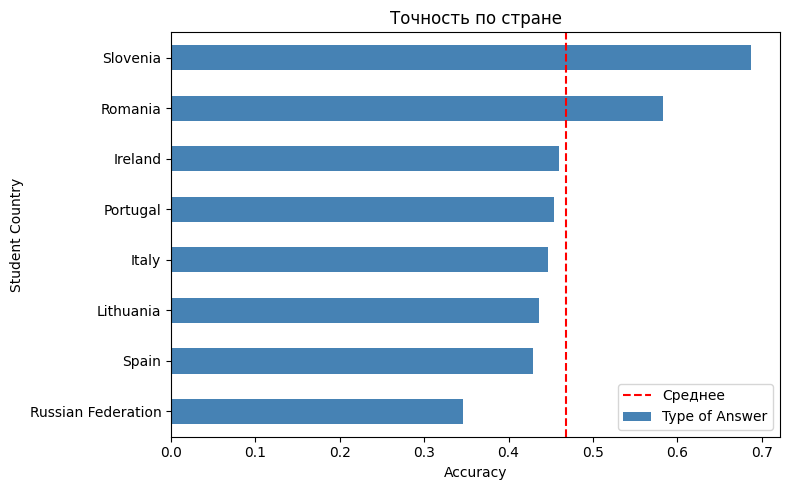

In [29]:
print(df.groupby('Student Country')['Type of Answer']
      .agg(['count', 'mean'])
      .rename(columns={'count': 'Попытки', 'mean': 'Accuracy'})
      .sort_values('Accuracy', ascending=False)
      .round(3))

fig, ax = plt.subplots(figsize=(8, 5))

country_acc = df.groupby('Student Country')['Type of Answer'].mean().sort_values()
country_acc.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(df['Type of Answer'].mean(), color='red', linestyle='--', label='Среднее')
ax.set_title('Точность по стране')
ax.set_xlabel('Accuracy')
ax.legend()

plt.tight_layout()
plt.show()


Вот тут за нашу страну обидно, она внизу списка....

#### Точность по темам

                                     Попытки  Accuracy
Topic                                                 
Set Theory                                42     0.643
Graph Theory                              55     0.582
Differential Equations                   108     0.537
Linear Algebra                          5726     0.490
Analytic Geometry                        358     0.489
Statistics                               340     0.479
Fundamental Mathematics                  818     0.466
Complex Numbers                          592     0.454
Integration                              144     0.444
Numerical Methods                        310     0.387
Optimization                             182     0.385
Probability                              128     0.375
Real Functions of a single variable      164     0.354
Differentiation                          579     0.342


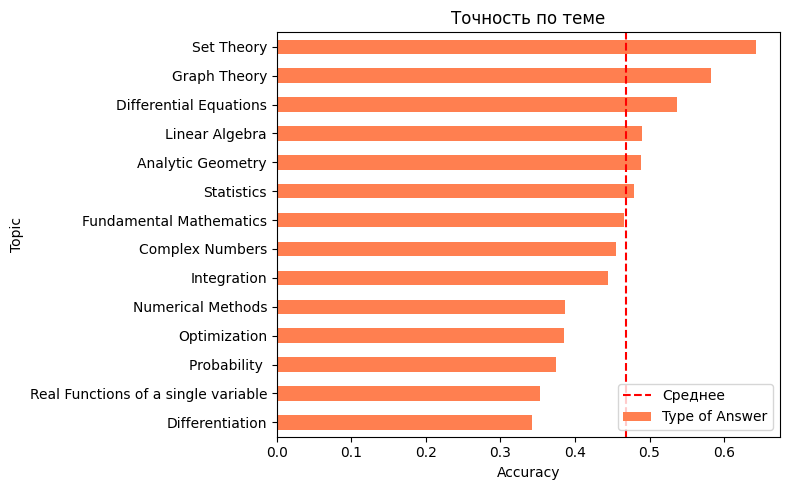

In [30]:
print(df.groupby('Topic')['Type of Answer']
      .agg(['count', 'mean'])
      .rename(columns={'count': 'Попытки', 'mean': 'Accuracy'})
      .sort_values('Accuracy', ascending=False)
      .round(3))

fig, ax = plt.subplots(figsize=(8, 5))

topic_acc = df.groupby('Topic')['Type of Answer'].mean().sort_values()
topic_acc.plot(kind='barh', ax=ax, color='coral')
ax.axvline(df['Type of Answer'].mean(), color='red', linestyle='--', label='Среднее')
ax.set_title('Точность по теме')
ax.set_xlabel('Accuracy')
ax.legend()

plt.tight_layout()
plt.show()



Легкими темами оказались: Теория множеств, Теория графов, Дифференциальные уравнения, Линейная алгебра
Сложные темы: Дифференцирование,  Функции одной переменной, Вероятность

### 3. Предобработка данных

создаём датасет на уровне студента

In [31]:
student_df = df.groupby('Student ID').agg(
    country        = ('Student Country', 'first'),
    total_attempts = ('Type of Answer',  'count'),
    correct        = ('Type of Answer',  'sum'),
).reset_index()
student_df['accuracy'] = student_df['correct'] / student_df['total_attempts']

Количество попыток по каждой теме

In [32]:
topic_pivot = df.pivot_table(
    index='Student ID', columns='Topic',
    values='Type of Answer', aggfunc='count', fill_value=0
).reset_index()
topic_pivot.columns.name = None
print(topic_pivot)

     Student ID  Analytic Geometry  Complex Numbers  Differential Equations  \
0            26                 27                0                      21   
1            28                 36                7                       0   
2            36                  0                0                       0   
3            37                  7               14                       3   
4            41                 12                7                       7   
..          ...                ...              ...                     ...   
367        1552                  0                0                       0   
368        1557                  0                0                       7   
369        1561                  0                0                       1   
370        1564                  0                0                       0   
371        1565                  0                0                       1   

     Differentiation  Fundamental Mathematics  Grap

Количество продвинутых (Advanced) вопросов у студента

In [33]:
adv = (df[df['Question Level'] == 'Advanced']
       .groupby('Student ID').size()
       .rename('adv_attempts'))
print(adv)

Student ID
36       7
37      14
41       5
64       1
72      35
        ..
1517    63
1525    13
1557    37
1561     9
1565     3
Name: adv_attempts, Length: 126, dtype: int64


Количество уникальных вопросов

In [34]:
uniq_q = df.groupby('Student ID')['Question ID'].nunique().rename('unique_questions')
print(uniq_q)

Student ID
26       64
28       47
36       35
37      120
41       57
       ... 
1552      2
1557     35
1561     10
1564     28
1565     15
Name: unique_questions, Length: 372, dtype: int64


собираем

In [35]:
feat = (student_df
        .merge(topic_pivot, on='Student ID', how='left')
        .merge(adv, on='Student ID', how='left')
        .merge(uniq_q, on='Student ID', how='left')
        .fillna({'adv_attempts': 0}))
print(feat)

     Student ID   country  total_attempts  correct  accuracy  \
0            26  Portugal              77       58  0.753247   
1            28  Portugal              59       35  0.593220   
2            36  Portugal              35       18  0.514286   
3            37  Portugal             140       87  0.621429   
4            41  Portugal              59       34  0.576271   
..          ...       ...             ...      ...       ...   
367        1552  Portugal               2        0  0.000000   
368        1557  Portugal              58       22  0.379310   
369        1561  Portugal              11        3  0.272727   
370        1564  Portugal              28        3  0.107143   
371        1565  Portugal              15        2  0.133333   

     Analytic Geometry  Complex Numbers  Differential Equations  \
0                   27                0                      21   
1                   36                7                       0   
2                    0        

переименовываем

In [36]:
feat = feat.rename(columns={
    'Differentiation': 'n_diff',
    'Linear Algebra':  'n_alg',
    'Real Functions of a single variable': 'n_rfunc',
    'Statistics': 'n_stat'
})


доля попыток по теме

In [37]:
for col in ['n_diff', 'n_alg', 'n_rfunc', 'n_stat']:
    feat[f'r_{col}'] = feat[col] / feat['total_attempts']

print(feat[['r_n_diff', 'r_n_alg', 'r_n_rfunc', 'r_n_stat']].describe().round(3))

       r_n_diff  r_n_alg  r_n_rfunc  r_n_stat
count   372.000  372.000    372.000   372.000
mean      0.088    0.473      0.018     0.143
std       0.258    0.469      0.112     0.346
min       0.000    0.000      0.000     0.000
25%       0.000    0.000      0.000     0.000
50%       0.000    0.431      0.000     0.000
75%       0.000    1.000      0.000     0.000
max       1.000    1.000      1.000     1.000


делал ли студент задачи по теме(доля студентов, решавших тему)

In [38]:
for col in ['n_diff', 'n_alg', 'n_rfunc', 'n_stat']:
    feat[f'has_{col[2:]}'] = (feat[col] > 0).astype(int)

flag_cols = ['has_diff', 'has_alg', 'has_rfunc', 'has_stat']
print(feat[flag_cols].mean().round(3).rename('Доля студентов').to_string())

has_diff     0.140
has_alg      0.551
has_rfunc    0.043
has_stat     0.156


In [39]:
country_acc_map = df.groupby('Student Country')['Type of Answer'].mean()
feat['country_target_enc'] = feat['country'].map(country_acc_map)
print(country_acc_map.sort_values(ascending=False).round(3).to_string())

Student Country
Slovenia              0.687
Romania               0.583
Ireland               0.460
Portugal              0.454
Italy                 0.446
Lithuania             0.436
Spain                 0.429
Russian Federation    0.346


присваиваем номер

In [40]:
country_label = {'Ireland': 0, 'Lithuania': 1, 'Spain': 2, 'Italy': 3, 'Portugal': 4}
feat['country_code'] = feat['country'].map(country_label)

print(pd.Series(country_label, name='code').to_string())

Ireland      0
Lithuania    1
Spain        2
Italy        3
Portugal     4


финальные признаки, финальный датасет (после оптимизации)

In [41]:
feature_cols = [
    'country_code', 'country_target_enc',
    'total_attempts', 'unique_questions', 'adv_attempts',
    'n_alg', 'n_stat', 'n_diff', 'n_rfunc',
    'r_n_alg', 'r_n_stat', 'r_n_diff', 'r_n_rfunc',
    'has_alg', 'has_stat', 'has_diff', 'has_rfunc',
]

X = feat[feature_cols]
y = feat['accuracy']

print(f"Строк: {X.shape[0]}, Признаков: {X.shape[1]}")
print(f"Таргет (accuracy): min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")

Строк: 372, Признаков: 17
Таргет (accuracy): min=0.00, max=1.00, mean=0.45


Корреляция признаков

In [42]:
corr_df = X.copy()
corr_df['accuracy'] = y
corr_series = corr_df.corr()['accuracy'].drop('accuracy').sort_values(ascending=False).round(3)
print(corr_series.to_string())
best_feat = corr_series.idxmax()
print(f"\nСамый предсказательный признак: '{best_feat}' (r={corr_series[best_feat]})")

country_code          0.209
has_alg               0.192
r_n_alg               0.188
country_target_enc    0.113
adv_attempts          0.072
r_n_stat              0.050
n_alg                 0.048
has_stat              0.047
total_attempts        0.035
n_stat                0.034
unique_questions      0.009
r_n_rfunc            -0.023
has_rfunc            -0.037
n_rfunc              -0.042
n_diff               -0.078
has_diff             -0.232
r_n_diff             -0.308

Самый предсказательный признак: 'country_code' (r=0.209)


Тепловая карта корреляций

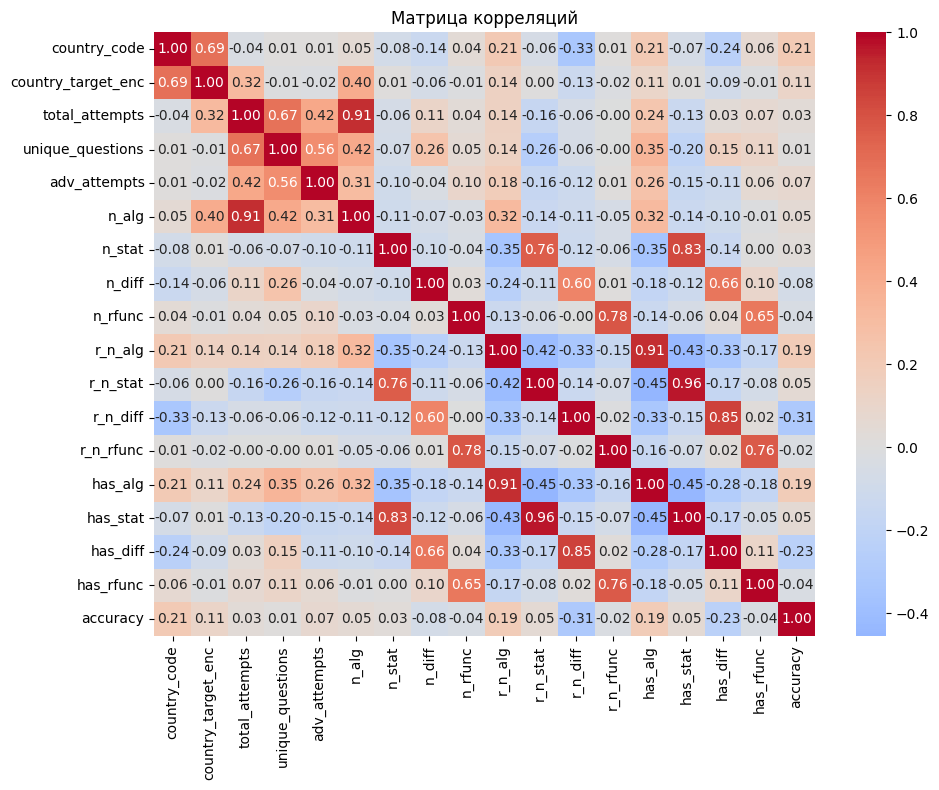

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

Разбивка на Train/Test

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Train: {X_train.shape[0]} строк ({X_train.shape[0]/X.shape[0]:.0%})")
print(f"Test:  {X_test.shape[0]} строк  ({X_test.shape[0]/X.shape[0]:.0%})")

Train: 297 строк (80%)
Test:  75 строк  (20%)


Масштабирование признаков

In [46]:
from sklearn.impute import SimpleImputer

# Заполнение пропусков средним
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Масштабирование признаков
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

# Полиномиальные признаки (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_sc)
X_test_poly  = poly.transform(X_test_sc)

print(f"X_train_sc : {X_train_sc.shape}")
print(f"X_train_poly: {X_train_poly.shape}")


X_train_sc : (297, 17)
X_train_poly: (297, 170)


### 4.Обучение нескольких моделей регрессии

In [48]:
models = {
    "LinearRegression": (LinearRegression(),                              X_train_sc,   X_test_sc),
    "Ridge":            (Ridge(alpha=1.0),                                X_train_sc,   X_test_sc),
    "Lasso":            (Lasso(alpha=0.05),                               X_train_sc,   X_test_sc),
    "ElasticNet":       (ElasticNet(alpha=0.05, l1_ratio=0.5),            X_train_sc,   X_test_sc),
    "Ridge poly2":      (Ridge(alpha=0.01),                               X_train_poly, X_test_poly),
    "DecisionTree":     (DecisionTreeRegressor(max_depth=4, random_state=42), X_train_sc, X_test_sc),
    "RandomForest":     (RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
                         X_train_sc, X_test_sc),
    "GradBoost":        (GradientBoostingRegressor(n_estimators=200, max_depth=2,
                          learning_rate=0.05, random_state=42), X_train_sc, X_test_sc),
    "SVR":              (SVR(kernel='rbf', C=5, epsilon=0.05),            X_train_sc,   X_test_sc),
}

trained_models = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    trained_models[name] = (model, Xtr, Xte)

### 5. Метрики

In [54]:
def Reg_Models_Evaluation_Metrics(name, model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    r2     = metrics.r2_score(y_te, y_pred)
    n, p   = X_te.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    rmse   = np.sqrt(metrics.mean_squared_error(y_te, y_pred))
    mae    = metrics.mean_absolute_error(y_te, y_pred)
    cv_r2  = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    r2_tr  = metrics.r2_score(y_tr, model.predict(X_tr))

    print(f"\n{'─'*45}")
    print(f"  Модель:          {name}")
    print(f"  R^2 train:        {r2_tr:.4f}")
    print(f"  R^2 test:         {r2:.4f}")
    print(f"  Adj R^2:          {adj_r2:.4f}")
    print(f"  CV R^2 (5-fold):  {cv_r2:.4f}")
    print(f"  RMSE:            {rmse:.4f}")
    print(f"  MAE:             {mae:.4f}")
    return {
        'Model':    name,
        'R^2_train': round(r2_tr, 4),
        'R^2_test':  round(r2,    4),
        'Adj_R^2':   round(adj_r2, 4),
        'CV_R^2':    round(cv_r2,  4),
        'RMSE':     round(rmse,   4),
        'MAE':      round(mae,    4),
        'y_pred':   y_pred
    }

опеределение моделей

In [55]:
models = {
    "LinearRegression": (LinearRegression(),                                          X_train_sc,   X_test_sc),
    "Ridge":            (Ridge(alpha=1.0),                                            X_train_sc,   X_test_sc),
    "Lasso":            (Lasso(alpha=0.05),                                           X_train_sc,   X_test_sc),
    "ElasticNet":       (ElasticNet(alpha=0.05, l1_ratio=0.5),                        X_train_sc,   X_test_sc),
    "Ridge poly2":      (Ridge(alpha=0.01),                                           X_train_poly, X_test_poly),
    "DecisionTree":     (DecisionTreeRegressor(max_depth=4, random_state=42),         X_train_sc,   X_test_sc),
    "RandomForest":     (RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42), X_train_sc, X_test_sc),
    "GradBoost":        (GradientBoostingRegressor(n_estimators=200, max_depth=2,
                          learning_rate=0.05, random_state=42),                       X_train_sc,   X_test_sc),
    "SVR":              (SVR(kernel='rbf', C=5, epsilon=0.05),                        X_train_sc,   X_test_sc),
}


Обучаем и считаем метрики для каждой модели

In [56]:
all_results = []

for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    res = Reg_Models_Evaluation_Metrics(
        name  = name,
        model = model,
        X_tr  = Xtr,
        y_tr  = y_train,
        X_te  = Xte,
        y_te  = y_test
    )
    all_results.append(res)


─────────────────────────────────────────────
  Модель:          LinearRegression
  R^2 train:        0.1580
  R^2 test:         0.0882
  Adj R^2:          -0.1837
  CV R^2 (5-fold):  -0.0185
  RMSE:            0.2520
  MAE:             0.1932

─────────────────────────────────────────────
  Модель:          Ridge
  R^2 train:        0.1578
  R^2 test:         0.0931
  Adj R^2:          -0.1774
  CV R^2 (5-fold):  0.0304
  RMSE:            0.2513
  MAE:             0.1936

─────────────────────────────────────────────
  Модель:          Lasso
  R^2 train:        0.0501
  R^2 test:         0.0447
  Adj R^2:          -0.2402
  CV R^2 (5-fold):  0.0368
  RMSE:            0.2579
  MAE:             0.2075

─────────────────────────────────────────────
  Модель:          ElasticNet
  R^2 train:        0.0885
  R^2 test:         0.0965
  Adj R^2:          -0.1730
  CV R^2 (5-fold):  0.0640
  RMSE:            0.2508
  MAE:             0.2006

─────────────────────────────────────────────
  Мо

сводная таблица для наглядности

In [60]:
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred'}
                        for r in all_results])
res_df = res_df.sort_values('R^2_test', ascending=False).reset_index(drop=True)

print(res_df.to_string(index=False))

           Model  R^2_train  R^2_test  Adj_R^2    CV_R^2   RMSE    MAE
    RandomForest     0.3904    0.1269  -0.1336    0.0505 0.2466 0.1869
      ElasticNet     0.0885    0.0965  -0.1730    0.0640 0.2508 0.2006
           Ridge     0.1578    0.0931  -0.1774    0.0304 0.2513 0.1936
LinearRegression     0.1580    0.0882  -0.1837   -0.0185 0.2520 0.1932
       GradBoost     0.4020    0.0566  -0.2247    0.0875 0.2563 0.1977
    DecisionTree     0.2984    0.0539  -0.2282   -0.0064 0.2567 0.1932
           Lasso     0.0501    0.0447  -0.2402    0.0368 0.2579 0.2075
             SVR     0.2922    0.0186  -0.2740   -0.0403 0.2614 0.1998
     Ridge poly2     0.3500 -258.2728 200.8561 -430.0762 4.2488 0.8340


Все модели показали очень низкий R2 (максимум 0.13). Скорее всего это свойство данных в датасете. Точность студента почти полностью состоит из шума, потому что 62% студентов имеют лишь 1 попытку. Возможно мало признаков с сильной корреляцией

In [61]:
best = res_df.iloc[0]
print(f"\n Лучшая модель: {best['Model']}")
print(f"   R^2 test  = {best['R^2_test']}")
print(f"   CV R^2    = {best['CV_R^2']}")
print(f"   RMSE     = {best['RMSE']}")
print(f"   MAE      = {best['MAE']}")


 Лучшая модель: RandomForest
   R^2 test  = 0.1269
   CV R^2    = 0.0505
   RMSE     = 0.2466
   MAE      = 0.1869


### 6.Визуализация регрессии

сделаем визуализацию на лучшем признаке (r_n_alg)

In [64]:
feature_name = 'r_n_alg'
X_single = feat[[feature_name]].values
y_single  = feat['accuracy'].values

model_viz = LinearRegression()
model_viz.fit(X_single, y_single)

x_line = np.linspace(X_single.min(), X_single.max(), 200).reshape(-1, 1)
y_line = model_viz.predict(x_line)
r2_viz = metrics.r2_score(y_single, model_viz.predict(X_single))

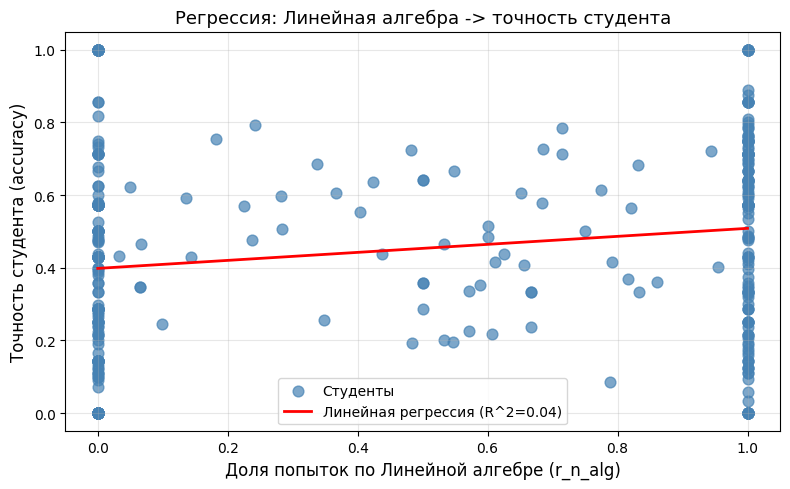

In [67]:
plt.figure(figsize=(8, 5))
plt.scatter(X_single, y_single,
            color='steelblue', alpha=0.7, s=60, label='Студенты')
plt.plot(x_line, y_line,
         color='red', linewidth=2,
         label=f'Линейная регрессия (R^2={r2_viz:.2f})')
plt.xlabel('Доля попыток по Линейной алгебре (r_n_alg)', fontsize=12)
plt.ylabel('Точность студента (accuracy)', fontsize=12)
plt.title('Регрессия: Линейная алгебра -> точность студента', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Линейная регрессия зависимости точности студента от доли попыток по теме динейная алгебра. 
    1. Красная линия (регрессия) имеет положительный наклон (чем больше студент решал задач по Линейной алгебре, тем выше его средняя точность)
    2. модель объясняет лишь 4% дисперсии точности студентов (r2 = 0.04). этот признак слабо предсказывает результат в одиночку
    3. Точки сильно разбросаны. студенты, решавшие только задачи по алгебре, показывают точность (accuracy) от 0 до 1
Большинство студентов либо вообще не решали задачи по алгебре, либо решали только их. Один признак не может хорошо описать точность студента. Несмотря на то что линейная алгебра самый предсказательный признак в датасете (r=0.45), его одного недостаточно.